# Deep Models vs. Ground Truth — recall@k for NB06–08

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
import scipy.sparse as sp

In [3]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
# ART_DIR = Path('../artifacts'); DATA_DIR = Path('../r4.1')
ART_DIR = Path('/content/drive/MyDrive/artifacts')
DATA_DIR = Path('/content/drive/MyDrive/r4.1')
keras.utils.set_random_seed(42)

## Ground truth, proxy label, and evaluation protocol

Every model is trained to reproduce consensus_loose (the 90-user proxy). To score all 1,000 users without a model ever ranking a user it trained on, we use 5-fold out-of-fold prediction: within each fold a model trains on four folds (with an inner validation split for early stopping) and predicts the held-out fold. The assembled 1,000-length score vector is then ranked, and we read off recall@k and the explicit rank of each of the three real insiders. With only three positives, a test-set AUC is meaningless, so recall@k against the answer key is the only honest metric.

In [4]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet').reset_index(drop=True)
lab = pd.read_parquet(ART_DIR / 'cert_dataset_with_anomaly_labels.parquet')
gt = pd.read_csv(ART_DIR / 'cert_ground_truth_labels.csv')
users = fe['user'].tolist()
y = fe['consensus_loose'].astype(int).values
insiders = gt.loc[gt['insider'] == 1, 'user'].tolist()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
len(users), int(y.sum()), insiders

(1000, 90, ['ABB0427', 'KTW0365', 'HFC0492'])

### Evaluation helpers
All scores are aligned to users (position 0…999). Higher probabilities are more anomalous for the trained models and the engineered activity_anomaly_score; Isolation-Forest / LOF scores are more anomalous when more negative.

In [5]:
def rank_of(score, higher=True):
    r = pd.Series(score, index=users).rank(ascending=not higher, method='min')
    return {u: int(r[u]) for u in insiders}

def recall_at_k(score, higher=True, ks=(10, 20, 50, 100)):
    r = pd.Series(score, index=users).rank(ascending=not higher, method='min')
    return {k: int(sum(int(r[u]) <= k for u in insiders)) for k in ks}

### Focal loss and the out-of-fold runner
The same focal loss used to train the models in NB06–08 drives training here. The runner carves an inner validation set from each fold's training rows so early stopping never sees the held-out fold.

In [6]:
def focal_elements(y_true, y_pred, alpha=0.75, gamma=2.0):
    eps = keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    y_true = tf.cast(y_true, y_pred.dtype)
    p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
    a_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
    return -a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t)

def focal_loss(alpha=0.75, gamma=2.0):
    return lambda yt, yp: tf.reduce_mean(focal_elements(yt, yp, alpha, gamma))

In [7]:
def oof_predict(build_fn, make_inputs, epochs=120, batch=32):
    oof = np.zeros(len(users), dtype='float32')
    for tr_all, va in cv.split(np.zeros(len(y)), y):
        tr, val = train_test_split(tr_all, test_size=0.2, random_state=42, stratify=y[tr_all])
        Xtr, Xval, Xva = make_inputs(tr, val, va)
        keras.utils.set_random_seed(42)
        model = build_fn()
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=focal_loss(),
                      metrics=[keras.metrics.AUC(name='pr_auc', curve='PR')])
        cb = [keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                                            patience=15, restore_best_weights=True),
              keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                                patience=6, min_lr=1e-4)]
        model.fit(Xtr, y[tr], validation_data=(Xval, y[val]),
                  epochs=epochs, batch_size=batch, callbacks=cb, verbose=0)
        oof[va] = model.predict(Xva, verbose=0).ravel()
    return oof

## 1. Multi-input NN (NB06)

The branched network from Notebook 06, rebuilt from its saved manifest and scored out-of-fold.

In [8]:
branches = json.load(open(ART_DIR / 'dl_branch_manifest.json'))
branch_dims = {n: len(f) for n, f in branches.items()}

def build_branched(dims):
    inp, enc = [], []
    for n, d in dims.items():
        i = layers.Input(shape=(d,), name=f'{n}_in')
        x = layers.Dense(max(16, 2 * d), activation='relu')(i)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(max(8, d), activation='relu')(x)
        inp.append(i); enc.append(x)
    h = layers.Concatenate()(enc)
    h = layers.Dense(48, activation='relu')(h)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.4)(h)
    h = layers.Dense(24, activation='relu')(h)
    h = layers.Dropout(0.3)(h)
    return keras.Model(inp, layers.Dense(1, activation='sigmoid')(h))

In [9]:
def branch_inputs(table, branch_def):
    def make(tr, val, va):
        scalers = {}
        def block(ix, fit=False):
            out = []
            for n, feats in branch_def.items():
                b = table.iloc[ix][feats].fillna(0).values.astype('float32')
                if fit:
                    scalers[n] = StandardScaler().fit(b)
                out.append(scalers[n].transform(b).astype('float32'))
            return out
        return block(tr, True), block(val), block(va)
    return make

oof_mi = oof_predict(lambda: build_branched(branch_dims), branch_inputs(fe, branches))
rank_of(oof_mi)

{'ABB0427': 1, 'KTW0365': 75, 'HFC0492': 528}

## 2. Enhanced multimodal NN (NB07)

The same branched design widened with the email and HTTP features engineered in Notebook 07. We reload the enhanced feature table and its branch manifest and align rows to the shared user order.

In [10]:
enh = pd.read_parquet(ART_DIR / 'cert_enhanced_multimodal.parquet')
enh = enh.set_index('user').reindex(users).reset_index()
enh_branches = json.load(open(ART_DIR / 'dl_enhanced_branch_manifest.json'))
enh_dims = {n: len(f) for n, f in enh_branches.items()}
oof_enh = oof_predict(lambda: build_branched(enh_dims), branch_inputs(enh, enh_branches))
rank_of(oof_enh)

{'ABB0427': 1, 'KTW0365': 94, 'HFC0492': 593}

## 3. LSTM on weekly sequences (NB08)

Per-user weekly activity counts for logon, device and file events, rebuilt from the raw logs exactly as in Notebook 08. Each fold standardises the sequences using its own training statistics.

In [11]:
def weekly_counts(path):
    df = pd.read_csv(path, usecols=['date', 'user'])
    df['date'] = pd.to_datetime(df['date'])
    df['week'] = df['date'].dt.to_period('W')
    return df.groupby(['user', 'week']).size().unstack(fill_value=0)

logon_mat = weekly_counts(DATA_DIR / 'logon.csv')
device_mat = weekly_counts(DATA_DIR / 'device.csv')
file_mat = weekly_counts(DATA_DIR / 'file.csv')
all_weeks = sorted(set(logon_mat.columns) | set(device_mat.columns) | set(file_mat.columns))

def align(mat):
    return (mat.reindex(index=users, columns=all_weeks, fill_value=0)
               .fillna(0).values.astype('float32'))

seq = np.log1p(np.stack([align(logon_mat), align(device_mat), align(file_mat)], axis=-1))
seq.shape

(1000, 73, 3)

In [12]:
def build_lstm():
    i = layers.Input(shape=(seq.shape[1], seq.shape[2]))
    x = layers.LSTM(32, return_sequences=True)(i)
    x = layers.LSTM(16)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)
    return keras.Model(i, layers.Dense(1, activation='sigmoid')(x))

def seq_inputs(tr, val, va):
    mu = seq[tr].mean(axis=(0, 1), keepdims=True)
    sd = seq[tr].std(axis=(0, 1), keepdims=True) + 1e-6
    s = (seq - mu) / sd
    return s[tr], s[val], s[va]

oof_lstm = oof_predict(build_lstm, seq_inputs)
rank_of(oof_lstm)

{'ABB0427': 125, 'KTW0365': 275, 'HFC0492': 98}

## 4. Transformer (NB08)

The feature-tokenizer Transformer over the tabular matrix, standardised per fold.

In [13]:
feat_cols = [c for c in json.load(open(ART_DIR / 'model_feature_list.json'))
             if c != 'behavior_cluster']
Xtab = fe[feat_cols].fillna(0).values.astype('float32')

class FeatureTokenizer(layers.Layer):
    def __init__(self, d_model, **kw):
        super().__init__(**kw); self.d_model = d_model
    def build(self, input_shape):
        n = int(input_shape[-1])
        self.w = self.add_weight(name='w', shape=(n, self.d_model), initializer='glorot_uniform')
        self.b = self.add_weight(name='b', shape=(n, self.d_model), initializer='zeros')
    def call(self, x):
        return x[:, :, None] * self.w[None] + self.b[None]

class CLSToken(layers.Layer):
    def build(self, input_shape):
        self.cls = self.add_weight(name='cls', shape=(1, 1, int(input_shape[-1])),
                                   initializer='random_normal')
    def call(self, x):
        b = tf.shape(x)[0]
        return tf.concat([tf.tile(self.cls, [b, 1, 1]), x], axis=1)

In [14]:
def build_transformer(n_features=Xtab.shape[1], d_model=32, heads=4, blocks=2):
    inp = layers.Input(shape=(n_features,))
    x = FeatureTokenizer(d_model)(inp)
    x = CLSToken()(x)
    for _ in range(blocks):
        a = layers.MultiHeadAttention(num_heads=heads, key_dim=d_model // heads)(x, x)
        x = layers.LayerNormalization()(x + a)
        f = layers.Dense(2 * d_model, activation='relu')(x)
        f = layers.Dense(d_model)(f)
        x = layers.LayerNormalization()(x + f)
    cls = layers.Lambda(lambda t: t[:, 0])(x)
    cls = layers.Dropout(0.3)(cls)
    return keras.Model(inp, layers.Dense(1, activation='sigmoid')(cls))

def tab_inputs(tr, val, va):
    sc = StandardScaler().fit(Xtab[tr])
    X = sc.transform(Xtab).astype('float32')
    return X[tr], X[val], X[va]

oof_tr = oof_predict(build_transformer, tab_inputs)
rank_of(oof_tr)

{'ABB0427': 34, 'KTW0365': 179, 'HFC0492': 614}

## 5. GNN (NB08)

The GCN is transductive: it trains on the whole user-similarity graph with a training mask, so it gets its own out-of-fold loop. Each fold builds the kNN graph from features scaled on the training rows, trains with a focal-loss training mask, selects weights on the inner validation fold, and reads the held-out fold's node scores.

In [15]:
class GCNLayer(layers.Layer):
    def __init__(self, units, adj, activation=None, **kw):
        super().__init__(**kw); self.units = units; self.adj = adj
        self.activation = keras.activations.get(activation)
    def build(self, input_shape):
        self.w = self.add_weight(name='w', shape=(int(input_shape[-1]), self.units),
                                 initializer='glorot_uniform')
    def call(self, x):
        return self.activation(tf.matmul(self.adj, tf.matmul(x, self.w)))

def build_gcn(adj, n_features):
    inp = layers.Input(shape=(n_features,))
    x = GCNLayer(32, adj, activation='relu')(inp)
    x = layers.Dropout(0.4)(x)
    x = GCNLayer(16, adj, activation='relu')(x)
    return keras.Model(inp, GCNLayer(1, adj, activation='sigmoid')(x))

In [16]:
oof_gnn = np.zeros(len(users), dtype='float32')
for tr_all, va in cv.split(np.zeros(len(y)), y):
    tr, val = train_test_split(tr_all, test_size=0.2, random_state=42, stratify=y[tr_all])
    sc = StandardScaler().fit(Xtab[tr])
    X = sc.transform(Xtab).astype('float32')
    A = kneighbors_graph(X, 10, mode='connectivity', include_self=False)
    A = A.maximum(A.T) + sp.eye(A.shape[0])
    deg = np.asarray(A.sum(axis=1)).ravel()
    d_inv = sp.diags(1.0 / np.sqrt(deg))
    A_tf = tf.constant((d_inv @ A @ d_inv).toarray().astype('float32'))
    keras.utils.set_random_seed(42)
    gcn = build_gcn(A_tf, X.shape[1])
    X_all = tf.constant(X); y_all = tf.constant(y.astype('float32')[:, None])
    tm = tf.constant(np.isin(np.arange(len(y)), tr)); vm = np.isin(np.arange(len(y)), val)
    opt = keras.optimizers.Adam(1e-2); best, best_w, wait = -1.0, None, 0
    for epoch in range(300):
        with tf.GradientTape() as tape:
            logits = gcn(X_all, training=True)
            elem = focal_elements(y_all, logits)
            loss = tf.reduce_sum(tf.boolean_mask(elem, tm)) / tf.reduce_sum(tf.cast(tm, tf.float32))
        grads = tape.gradient(loss, gcn.trainable_variables)
        opt.apply_gradients(zip(grads, gcn.trainable_variables))
        vp = gcn(X_all, training=False).numpy().ravel()
        ap = average_precision_score(y[vm], vp[vm])
        if ap > best:
            best, best_w, wait = ap, gcn.get_weights(), 0
        else:
            wait += 1
            if wait >= 40:
                break
    gcn.set_weights(best_w)
    oof_gnn[va] = gcn(X_all, training=False).numpy().ravel()[va]
rank_of(oof_gnn)

{'ABB0427': 33, 'KTW0365': 34, 'HFC0492': 464}

## Baselines for reference

The unsupervised detector scores from Notebook 03 and the proxy-trained RandomForest from Notebook 09, carried in so the deep models are judged against the same yardsticks.

In [17]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
oof_rf = cross_val_predict(rf, fe[json.load(open(ART_DIR / 'model_feature_list.json'))].fillna(0).values,
                           y, cv=cv, method='predict_proba')[:, 1]
iso = lab.set_index('user')['iso_score'].reindex(users).values
lof = lab.set_index('user')['lof_score'].reindex(users).values
act = fe.set_index('user')['activity_anomaly_score'].reindex(users).values

## Master benchmark: recall@k vs the three real insiders

In [18]:
sources = {
    'MultiInput NN (06)': (oof_mi, True),
    'Multimodal NN (07)': (oof_enh, True),
    'LSTM (08)': (oof_lstm, True),
    'Transformer (08)': (oof_tr, True),
    'GNN (08)': (oof_gnn, True),
    'RF proxy (09)': (oof_rf, True),
    'iso_score': (iso, False),
    'lof_score': (lof, False),
    'activity_score': (act, True),
}
recall_tbl = pd.DataFrame({n: recall_at_k(s, h) for n, (s, h) in sources.items()}).T
recall_tbl.columns = [f'recall@{k}' for k in recall_tbl.columns]
recall_tbl.sort_values('recall@50', ascending=False)

,recall@10,recall@20,recall@50,recall@100
GNN (08),0,0,2,2
activity_score,2,2,2,2
MultiInput NN (06),1,1,1,2
Transformer (08),0,0,1,1
Multimodal NN (07),1,1,1,2
lof_score,0,1,1,1
LSTM (08),0,0,0,1
iso_score,0,0,0,2
RF proxy (09),0,0,0,0


In [19]:
rank_tbl = pd.DataFrame({n: rank_of(s, h) for n, (s, h) in sources.items()}).T
rank_tbl.index.name = 'model'
rank_tbl

,ABB0427,KTW0365,HFC0492
model,,,
MultiInput NN (06),1,75,528
Multimodal NN (07),1,94,593
LSTM (08),125,275,98
Transformer (08),34,179,614
GNN (08),33,34,464
RF proxy (09),137,113,295
iso_score,84,72,203
lof_score,183,11,804
activity_score,1,10,341


The unsupervised activity_score is still the best single detector (2/3 in the top 10), yet the proxy-trained deep networks clearly beat the proxy-trained RF proxy, which finds none of the three even in the top 100: the branched multi-input and multimodal NNs rank the loud insider ABB0427 first, and the GNN recovers 2/3 within the top 50. The decisive column is HFC0492 — the slow, late-stage thumb-drive exfiltration — where every aggregate model (tree, NNs, Transformer, GNN) buries it beyond rank ~450, and only the weekly LSTM pulls it to rank ~98.

## Recall within a review budget

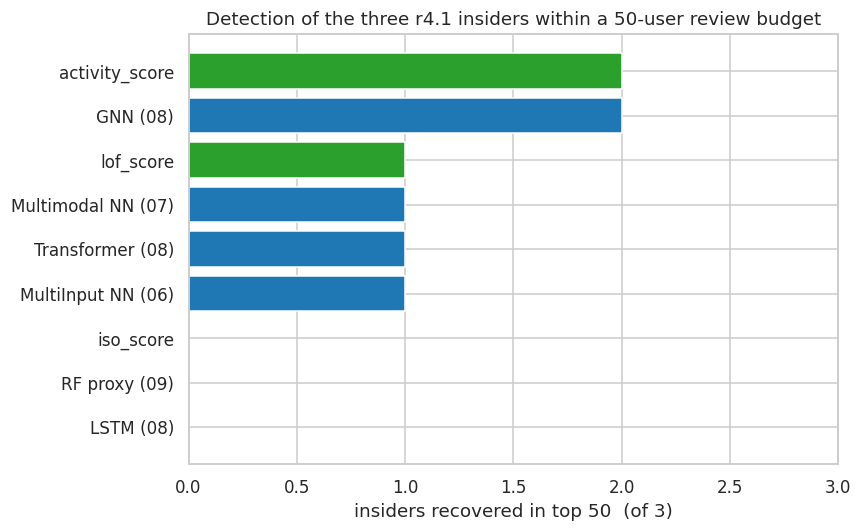

In [20]:
k = 50
col = f'recall@{k}'
order = recall_tbl.sort_values(col)
plt.figure(figsize=(8, 5))
colors = ['tab:green' if i in ('iso_score', 'lof_score', 'activity_score') else 'tab:blue'
          for i in order.index]
plt.barh(order.index, order[col], color=colors)
plt.xlabel(f'insiders recovered in top {k}  (of 3)')
plt.title(f'Detection of the three r4.1 insiders within a {k}-user review budget')
plt.xlim(0, 3)
plt.tight_layout()
plt.show()

green bars are unsupervised references, blue bars are proxy-trained models.

## Per-insider difficulty

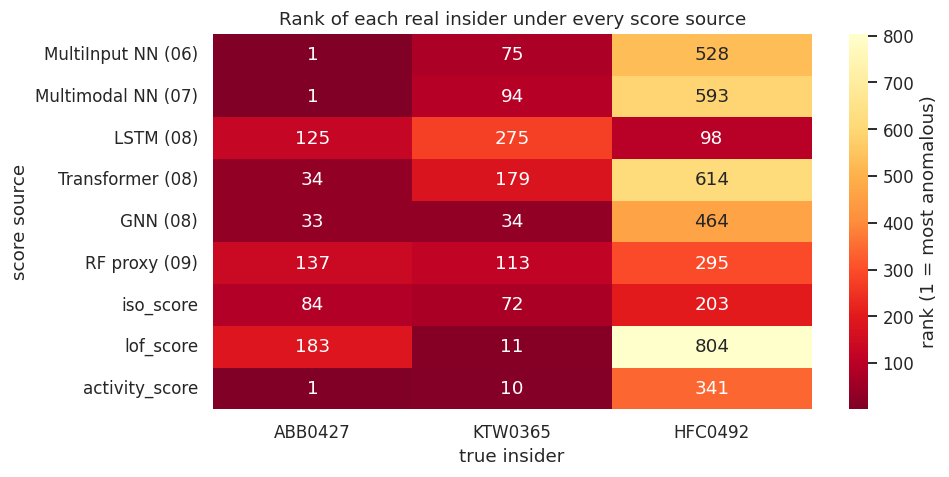

In [21]:
plt.figure(figsize=(9, 4.5))
sns.heatmap(rank_tbl[insiders], annot=True, fmt='d', cmap='YlOrRd_r',
            cbar_kws={'label': 'rank (1 = most anomalous)'})
plt.title('Rank of each real insider under every score source')
plt.ylabel('score source'); plt.xlabel('true insider')
plt.tight_layout()
plt.show()

In [22]:
scores_df = pd.DataFrame({n: s for n, (s, _) in sources.items()})
scores_df.insert(0, 'user', users)
scores_df.insert(1, 'insider', gt.set_index('user').reindex(users)['insider'].values)
scores_df.to_csv(ART_DIR / 'model_scores_vs_truth.csv', index=False)
recall_tbl.to_csv(ART_DIR / 'recall_at_k_vs_truth.csv')
rank_tbl.to_csv(ART_DIR / 'insider_ranks_vs_truth.csv')
sorted(p.name for p in ART_DIR.glob('*_vs_truth.csv'))

['insider_ranks_vs_truth.csv',
 'model_scores_vs_truth.csv',
 'recall_at_k_vs_truth.csv']